In [1]:
''' This does all the prep for making a BlendedMLP: it splits a mesh into patches
using geodesics, and parametrises the patches using Tutte's embedding. '''


import trimesh
import open3d as o3d
import numpy as np

from scipy.spatial import cKDTree
from mesh_processing import *
import matplotlib.pyplot as plt

import os
import shutil
from visuals import *

original_cwd = os.getcwd()

In [2]:
# Settings
shape_name = 'igea11706' #'torus4608' #'sphere4'   #'sphere2' #'camelhead'
target_number_of_triangles = 8

In [3]:
''' Load mesh (fine_mesh) and make a simplified mesh (coarse_mesh) '''

# Paths
off_filepath = f"data/surfaces/{shape_name}.off"
obj_filepath = f"data/surfaces/{shape_name}.obj"

# Check if .off file exists
if not os.path.exists(off_filepath):
    if os.path.exists(obj_filepath):
        print(f"{off_filepath} not found. Converting from .obj...")
        mesh = o3d.io.read_triangle_mesh(obj_filepath)
        mesh.vertex_normals = o3d.utility.Vector3dVector()  # Clear vertex normals
        mesh.triangle_normals = o3d.utility.Vector3dVector()  # Clear triangle normals
        o3d.io.write_triangle_mesh(off_filepath, mesh)
    else:
        raise FileNotFoundError(f"Neither {off_filepath} nor {obj_filepath} found.")

# Load mesh from .off
fine_mesh = o3d.io.read_triangle_mesh(off_filepath)

# Simplify mesh
simplified_mesh = fine_mesh.simplify_quadric_decimation(
    target_number_of_triangles=target_number_of_triangles
)

# Visualize meshes
o3d.visualization.draw_geometries([fine_mesh], window_name="Fine Mesh")
o3d.visualization.draw_geometries([simplified_mesh], window_name="Simplified Mesh")

n_triangles = np.asarray(simplified_mesh.triangles).shape[0]

patches_name = shape_name + '_'+str(n_triangles)+'patch'


os.makedirs('patches/'+patches_name, exist_ok=True)

V_fine = np.asarray(fine_mesh.vertices)
V_simp = np.asarray(simplified_mesh.vertices)

# Snap the simplified mesh vertices to the fine mesh vertices
coarse_vertex_indices = cKDTree(V_fine).query(V_simp)[1]
V_coarse = V_fine[coarse_vertex_indices]

# Create new mesh with snapped vertices
coarse_mesh = o3d.geometry.TriangleMesh(
    vertices=o3d.utility.Vector3dVector(V_coarse),
    triangles=simplified_mesh.triangles
)
coarse_mesh.compute_vertex_normals()

o3d.visualization.draw_geometries([coarse_mesh], window_name="Coarse Mesh")

o3d.io.write_triangle_mesh("patches/"+patches_name+"/coarse.obj", coarse_mesh)


[Open3D WARNING] Write OBJ can not include triangle normals.


True

In [4]:
# Make halfedge meshes, including a halfedge index for each vertex.
coarse_he_mesh, coarse_V_he = he_mesh_from_o3d(coarse_mesh)
fine_he_mesh, fine_V_he = he_mesh_from_o3d(fine_mesh)

Preparing V_he for halfedge mesh
Prepared V_he for halfedge mesh.

Preparing V_he for halfedge mesh
10000 of 70224
20000 of 70224
30000 of 70224
40000 of 70224
50000 of 70224
60000 of 70224
70000 of 70224
Prepared V_he for halfedge mesh.



Processed file saved as ../geodesic_matlab/data/igea11706.txt
Cutting the mesh along curve 1 of 12.
start: 2269 end: 5151

mesh has 11706 vertices, 23408 faces, 35112 edges
0 edges are boundary edges
shortest/longest edges are 0.00156933/0.0577901 = 0.0271557
enclosing XYZ box: X[-0.694878,0.69485] Y[-0.998168,0.999597] Z[-0.997057,0.996296]
approximate diameter of the mesh is 3.14577
min/max face angles are 3.99704/164.253 degrees

Path saved to ../paths/path.obj
Starting the cutting for curve number
Making a cut...
End of cutting section.


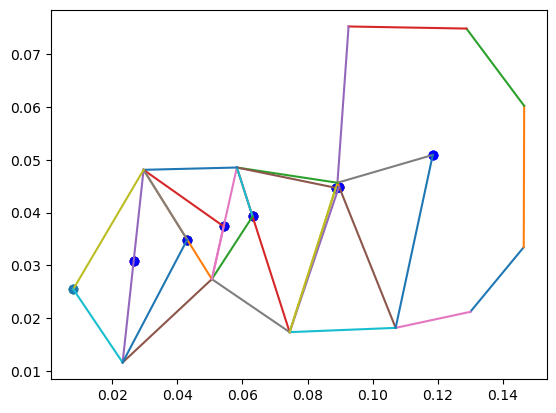

65 remaining
Making a cut...
End of cutting section.


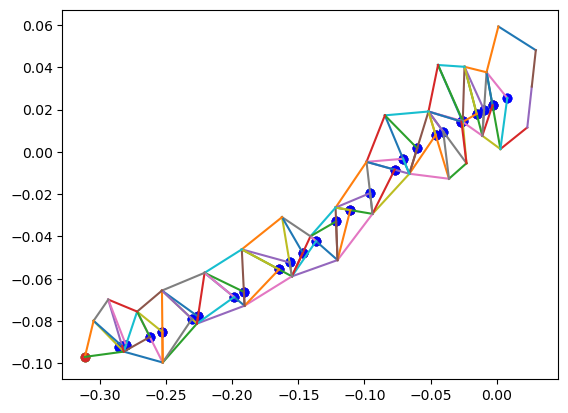

37 remaining
Making a cut...
End of cutting section.


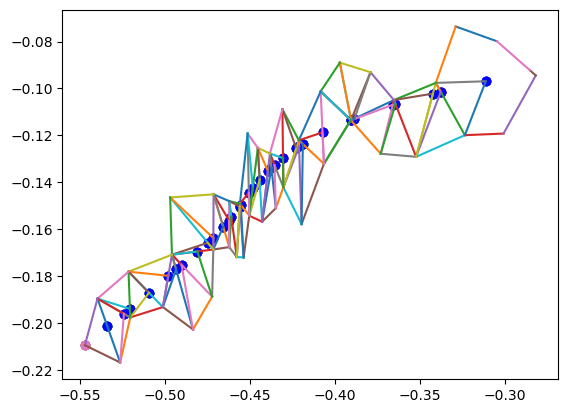

1 remaining
[7126, 11739, 11740, 11741, 11742, 11743, 11744, 11745, 11746, 11747, 11748, 11749, 11750, 11751, 11752, 11753, 11754, 11755, 11756, 11757, 11758, 11759, 11760, 11761, 11762, 11763, 11764, 11765, 11766, 11767, 11768, 11769, 11770, 11771, 11772, 11773, 5151]
Cutting the mesh along curve 2 of 12.
start: 5151 end: 4403

mesh has 11706 vertices, 23408 faces, 35112 edges
0 edges are boundary edges
shortest/longest edges are 0.00156933/0.0577901 = 0.0271557
enclosing XYZ box: X[-0.694878,0.69485] Y[-0.998168,0.999597] Z[-0.997057,0.996296]
approximate diameter of the mesh is 3.14577
min/max face angles are 3.99704/164.253 degrees

Path saved to ../paths/path.obj
Starting the cutting for curve number
Making a cut...
End of cutting section.


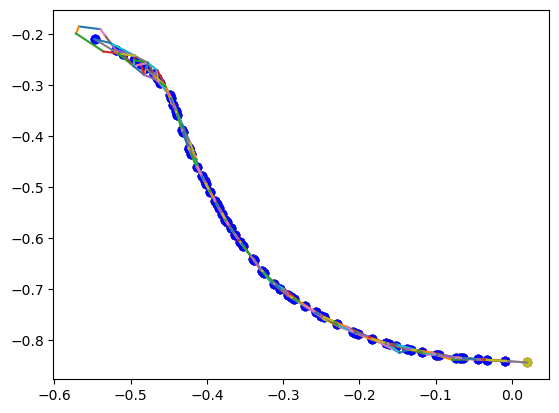

39 remaining
Making a cut...
End of cutting section.


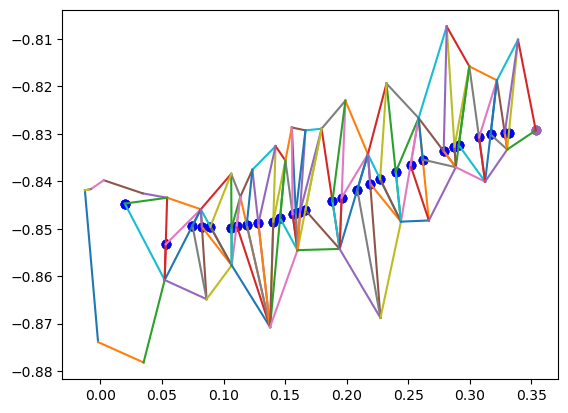

9 remaining
Making a cut...
End of cutting section.


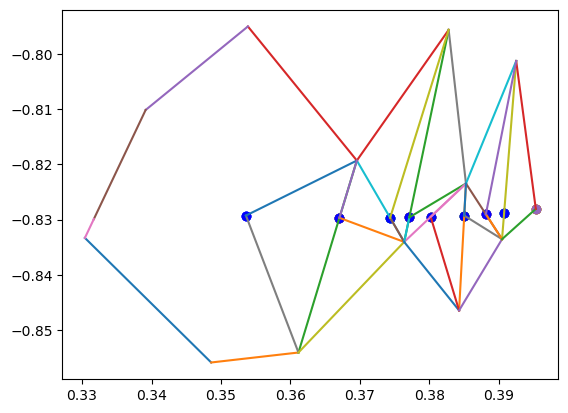

1 remaining
[4412, 11871, 11872, 11873, 11874, 11875, 11876, 11877, 4403]
Cutting the mesh along curve 3 of 12.
start: 4403 end: 2269

mesh has 11706 vertices, 23408 faces, 35112 edges
0 edges are boundary edges
shortest/longest edges are 0.00156933/0.0577901 = 0.0271557
enclosing XYZ box: X[-0.694878,0.69485] Y[-0.998168,0.999597] Z[-0.997057,0.996296]
approximate diameter of the mesh is 3.14577
min/max face angles are 3.99704/164.253 degrees

Path saved to ../paths/path.obj
Starting the cutting for curve number
Making a cut...
Point not on any segment.


TypeError: Oh no... the geodesic vertices should all lie on edges of the mesh.

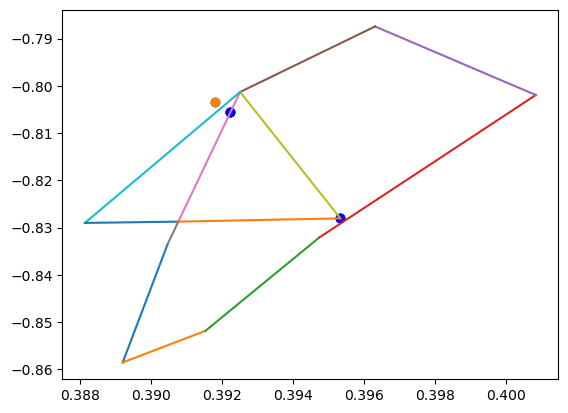

In [5]:
'''Find geodesics corresponding to coarse mesh vertices, and cut the fine mesh along the geodesics. '''

geodesic_vtx_indices = dict()
geodesic_pcds = []
half_edges = []

count = 1
total=len(coarse_he_mesh.half_edges)//2

os.system('cp data/surfaces/'+shape_name+'.off ../geodesic_matlab/data/'+shape_name+'.off' )
convert_off_file('../geodesic_matlab/data/'+shape_name+'.off', '../geodesic_matlab/data/'+shape_name+'.txt')

for i, he in enumerate(coarse_he_mesh.half_edges):

    v_id_start = coarse_vertex_indices [he.vertex_indices[0]]
    v_id_end = coarse_vertex_indices [he.vertex_indices[1]]

    if not ((v_id_start, v_id_end) in half_edges): # don't cut a halfedge if we already cut its twin
        
        print('Cutting the mesh along curve',str(count),'of',str(total)+'.')
        half_edges += [(v_id_start, v_id_end), (v_id_end, v_id_start)]
    
        print('start:', v_id_start, 'end:', v_id_end)
    
        # Call geodesic_matlab find_path
        os.chdir(original_cwd)
        os.chdir('../geodesic_matlab/src')  # or wherever `geodesic_matlab` is accessible from
        os.system('./find_path.out ../data/temp.txt '+str(v_id_end)+' '+str(v_id_start))
        os.chdir(original_cwd)
        
        geodesic_filepath = '../geodesic_matlab/paths/path.obj'
        os.system('cp ../geodesic_matlab/paths/path.obj patches/'+patches_name+'/path_'+str(i)+'.obj')
    
        fine_he_mesh, fine_V_he, geodesic_pcd, vtx_indices = cut_mesh_along_geodesic_v2(fine_he_mesh, fine_V_he, geodesic_filepath,
                                                                        v_id_start, v_id_end, debug_plot=True )

        geodesic_vtx_indices[i] = vtx_indices
        geodesic_vtx_indices[he.twin] = vtx_indices[::-1]
    
        geodesic_pcds.append(geodesic_pcd)
        print(vtx_indices)
    
        #o3d.visualization.draw_geometries([fine_he_mesh]+geodesic_pcds, window_name="Mesh Cutting Progress "+str(count)+" of "+str(total)+".")
    
        count+=1

o3d.visualization.draw_geometries([fine_he_mesh]+geodesic_pcds, window_name="Final Cut Mesh")
V_fine = np.asarray(fine_he_mesh.vertices)

In [ ]:
'''
# Debugging vertex indices
half_edges = coarse_he_mesh.half_edges
i=5

g1 = geodesic_vtx_indices[i]
g2 = geodesic_vtx_indices[half_edges[i].next]
g3 = geodesic_vtx_indices[half_edges[half_edges[i].next].next]

plt.plot(V_fine[g1][:,0], V_fine[g1][:,1], alpha=0.2)
plt.plot(V_fine[g2][:,0], V_fine[g2][:,1], alpha=0.2)
plt.plot(V_fine[g3][:,0], V_fine[g3][:,1], alpha=0.2)
plt.show()

print(g1)
print(g2)
print(g3)
'''


In [ ]:
''' Find all the halfedges that are part of a patch boundary (1st vertex, 2nd vertex) '''

coarse_half_edges = coarse_he_mesh.half_edges
fine_half_edges = fine_he_mesh.half_edges

all_bdry_halfedges = []

for i, he in enumerate(coarse_half_edges):

    g1 = geodesic_vtx_indices[i]
    g2 = geodesic_vtx_indices[he.next]
    g3 = geodesic_vtx_indices[coarse_half_edges[he.next].next]
    
    bdry_vertices = g1[:-1]+g2[:-1]+g3[:] # why??? bug.

    bdry_halfedges = list(zip(bdry_vertices, bdry_vertices[1:] + [bdry_vertices[0]]))

    #plt.plot(V_fine[bdry_vertices][:,0],V_fine[bdry_vertices][:,1],  alpha=0.2)
    #plt.show()

    all_bdry_halfedges = all_bdry_halfedges + bdry_halfedges
    
    #plt.plot(V_fine[g1][:,0], V_fine[g1][:,1], alpha=0.2)
    #plt.plot(V_fine[g2][:,0], V_fine[g2][:,1], alpha=0.2)
    #plt.plot(V_fine[g3][:,0], V_fine[g3][:,1], alpha=0.2)
    #plt.show()





In [ ]:
''' Do floodfill to find the patches, given their boundaries. '''


import mesh_processing
import importlib
importlib.reload(mesh_processing)
from mesh_processing import *


V = np.asarray(fine_he_mesh.vertices)
F = np.asarray(fine_he_mesh.triangles)

selected_faces = []
seed_he_index = 0

union_mask = np.array([False for i in range(len(F))])

patch_meshes = []



N = len(fine_half_edges)

while not np.all(union_mask): #while we have not accounted for all the faces
    selected_faces = floodfill(seed_he_index, fine_half_edges, all_bdry_halfedges, V)

    mask = np.array([i in selected_faces for i in range(len(F))]) #A is region inside
    #print(mask)

    if np.any(mask & ~union_mask): #does mask instroduce any new faces?
        F_part = F[mask]
        
        union_mask += mask
    
        # Create new mesh
        A = o3d.geometry.TriangleMesh()
        A.vertices = o3d.utility.Vector3dVector(V)
        A.triangles = o3d.utility.Vector3iVector(F_part)
        A.paint_uniform_color(np.random.random(3)) # assign a colour
        A.compute_vertex_normals()

        #o3d.visualization.draw_geometries([A])

        A.remove_unreferenced_vertices()
        patch_meshes.append(A)
        
    seed_he_index = np.random.randint(N) #choose a new seed. this can definitely be more optimal.
    
        
o3d.visualization.draw_geometries(patch_meshes)

#####################################################

''' Which patch corresponds to which coarse triangle? '''

patch_centroids = np.array( [np.asarray(patch.vertices).mean(0) for patch in patch_meshes] )


coarse_F = np.asarray( coarse_he_mesh.triangles )
coarse_V = np.asarray( coarse_he_mesh.vertices )

coarse_centroids = np.array( [ coarse_V[coarse_F[i]].mean(0) for i in range(coarse_F.shape[0]) ] )
#print(patch_centroids.shape)
#print(coarse_centroids.shape)

P = patch_centroids
C = coarse_centroids
P = P - P.mean()
C = C - C.mean()

M = P @ C.transpose(1,0) # correlation matrix
order = M.argmax(-1)
    
'''
# Testing that the patch-ordering is correct
for i,A in enumerate(patch_meshes):
    V_coarse = coarse_V[coarse_F[order[i]]]
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(V_coarse)

    o3d.visualization.draw_geometries([A, pcd])
'''

for i, A in enumerate(patch_meshes):
    triangle_id = order[i]
    o3d.io.write_triangle_mesh("patches/"+patches_name+"/"+str(triangle_id)+".obj", A)


    

In [ ]:
''' Add some special extra data to the patch obj files (the indices that correspond to corners) '''

# Loop over each mesh in `patch_meshes`
for i in range(n_triangles):

    A = o3d.io.read_triangle_mesh("patches/"+patches_name+"/"+str(i)+".obj")
    

    # Get the 3 vertices (abc) from coarse mesh
    abc = coarse_V[coarse_F[i]]  # `abc` should be a (3, 3) array

    # Convert mesh A's vertices to numpy array
    V = np.asarray(A.vertices)
    F = np.asarray(A.triangles)

    # Build a cKDTree for fast nearest-neighbor search in mesh A's vertices
    kdtree = cKDTree(V)

    # Find closest indices in V for each vertex in abc
    dist, closest_indices = kdtree.query(abc)  # The result should be an array of shape (3,) with the indices

    print('dist', dist)
    # Create the comment with the special indices
    comment = f"# Coarse Triangle Correspondence: {closest_indices[0]}, {closest_indices[1]}, {closest_indices[2]}"

    # Save the mesh to a temporary .obj file using Open3D
    obj_file_path = f"patches/{patches_name}/{i}.obj"
    o3d.io.write_triangle_mesh(obj_file_path, A)

    # Open the file and insert the comment at the top
    with open(obj_file_path, "r") as file:
        lines = file.readlines()

    # Prepend the comment line to the file content
    lines.insert(0, comment + "\n")

    # Write the content back to the file
    with open(obj_file_path, "w") as file:
        file.writelines(lines)

    print(f"Triangle {i}: Closest indices in V for abc: {closest_indices}")
    print(f"Mesh saved at: {obj_file_path} with special indices as comments.")

In [ ]:
''' Finally, parametrise the triangles and save as {i}_param.obj '''


import importlib
import visuals
importlib.reload(visuals)

from visuals import *

import mesh_processing
importlib.reload(mesh_processing)

from mesh_processing import *


for i in range(n_triangles):
    input_filename = "patches/"+patches_name+"/"+str(i)+".obj"
    output_filename = "patches/"+patches_name+"/"+str(i)+"_param.obj"
    tutte_embedding(input_filename, output_filename, visualise=False)